In [29]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore

from sklearn.model_selection import train_test_split # type: ignore
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve,roc_auc_score,accuracy_score,classification_report)


import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
#Loading the dataset
df = pd.read_csv("Loan_default.csv")

#Dislpay shape of the dataset
print("Dataset Shape:", df.shape)
print()

# Drop LoanID and target separation
X = df.drop(columns=['LoanID', 'Default'])
y = df['Default']

# Count of each class
class_counts = y.value_counts()

# Percentage of each class
class_percentage = y.value_counts(normalize=True) * 100

print("Class Distribution:\n")

print("Counts:")
print(class_counts)

print("\nPercentages:")
print(class_percentage)

Dataset Shape: (255347, 18)

Class Distribution:

Counts:
Default
0    225694
1     29653
Name: count, dtype: int64

Percentages:
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


In [31]:
# Define feature lists
numerical_features = [
    "Age", "Income", "LoanAmount", "CreditScore",
    "MonthsEmployed", "NumCreditLines", "InterestRate",
    "LoanTerm", "DTIRatio"
]

categorical_features = [
    "Education", "EmploymentType", "MaritalStatus",
    "HasMortgage", "HasDependents",
    "LoanPurpose", "HasCoSigner"
]

In [32]:
# Define ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [33]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner'],
      dtype='str')


In [34]:
# Preprocess the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [35]:
# Handle class imbalance with SMOTE
sm = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_processed, y_train)

In [36]:
# Build Improved Neural Network
model = keras.Sequential([
    
    layers.Dense(128, activation='relu', input_shape=(X_train_res.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',      # metric to monitor
    patience=5,              # epochs to wait before stopping
    restore_best_weights=True
)

# Train Model
history = model.fit(
    X_train_res,
    y_train_res,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

#Summary of the model
print("\nModel Summary\n")
model.summary()

Epoch 1/40


c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9028/9028 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.7100 - loss: 0.5625 - val_accuracy: 0.5704 - val_loss: 0.7511
Epoch 2/40
9028/9028 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.7259 - loss: 0.5428 - val_accuracy: 0.6856 - val_loss: 0.5892
Epoch 3/40
9028/9028 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.7510 - loss: 0.5101 - val_accuracy: 0.6492 - val_loss: 0.6539
Epoch 4/40
9028/9028 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.7732 - loss: 0.4773 - val_accuracy: 0.6922 - val_loss: 0.5769
Epoch 5/40
9028/9028 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.7881 - loss: 0.4545 - val_accuracy: 0.7334 - val_loss: 0.5293
Epoch 6/40
9028/9028 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.7986 - loss: 0.4384 - val_accuracy: 0.7791 - val_loss: 0.4097
Epoch 7/40
9028/9028 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8049 - loss: 0.4280 - val_accuracy: 0.7138 - val_loss: 0.5230
Epoch 8/40
9028/9028 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8087 - loss: 0.4228 - val

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,501 (166.02 KB)

 Trainable params: 14,017 (54.75 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 28,036 (109.52 KB)

1596/1596 ━━━━━━━━━━━━━━━━━━━━ 1s 691us/step

ROC AUC Score: 0.755526510967309
Best Threshold (ROC): 0.19270206987857819

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.68      0.79     45139
           1       0.22      0.70      0.34      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.57     51070
weighted avg       0.86      0.68      0.74     51070



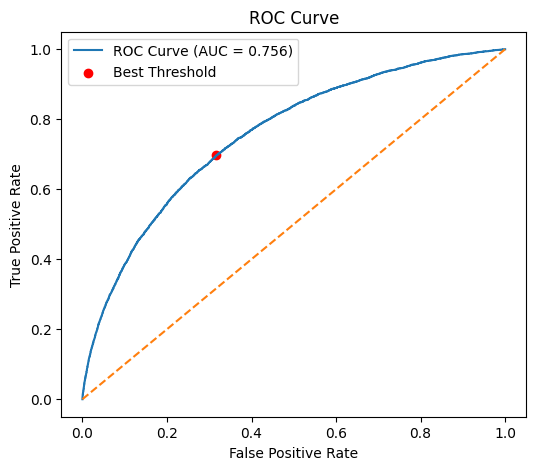

In [37]:
# Predict probabilities
y_probs = model.predict(X_test_processed).ravel()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# ROC AUC score
roc_auc = roc_auc_score(y_test, y_probs)
print("\nROC AUC Score:", roc_auc)

# Find best threshold using Youden's J statistic
J = tpr - fpr
best_idx = np.argmax(J)
best_threshold = thresholds[best_idx]

print("Best Threshold (ROC):", best_threshold)

# Convert probabilities to class predictions
y_pred = (y_probs >= best_threshold).astype(int)

# Classification report
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.scatter(fpr[best_idx], tpr[best_idx], color="red", label="Best Threshold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

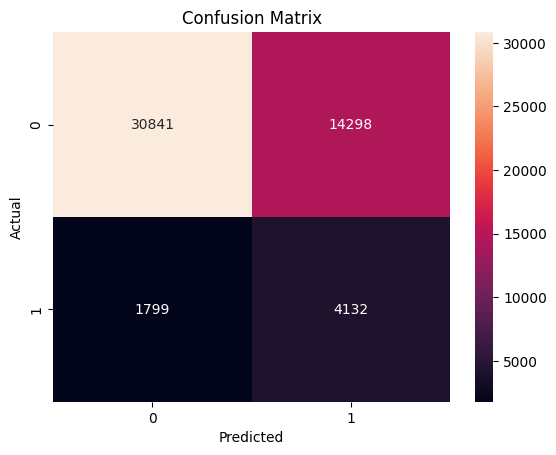

In [38]:
# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
# Example new customer data for custom prediction
new_customer = pd.DataFrame({
    "Age":[46],
    "Income":[84208],
    "LoanAmount":[129188],
    "CreditScore":[451],
    "MonthsEmployed":[26],
    "NumCreditLines":[3],
    "InterestRate":[21.17],
    "LoanTerm":[24],
    "DTIRatio":[0.31],
    "Education":["Master's"],
    "EmploymentType":["Unemployed"],
    "MaritalStatus":["Divorced"],
    "HasMortgage":["Yes"],
    "HasDependents":["No"],
    "LoanPurpose":["Auto"],
    "HasCoSigner":["No"]
})

In [40]:
# Preprocess new customer data
new_customer_processed = preprocessor.transform(new_customer)

prediction_prob = model.predict(new_customer_processed)[0][0]

prediction = int(prediction_prob >= best_threshold)

if prediction == 1:
    print("Prediction: Loan Default")
else:
    print("Prediction: No Default")

# Display prediction, probability and threshold
print("Probability:", prediction_prob)
print("Threshold used:", best_threshold)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Prediction: Loan Default
Probability: 0.39323518
Threshold used: 0.19270206987857819
